# Thesis verdict: does synthetic pretraining improve on the real-only baseline?

One table per axis and stage: for every variant and key metric, is the improvement over the baseline significant (95 % interval above zero), significantly negative, or inconclusive; and do the targeted mechanisms improve their target classes against their matched controls?

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

* **Labels.** `improves`: interval entirely above zero; `worsens`: entirely below zero; `inconclusive`: otherwise.
  No correction for the many comparisons is applied; with 10 variants x 3 stages x 13 metric-evaluations per axis,
  isolated `improves` labels are expected by chance and only consistent patterns are interpreted.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "thesis_verdict"
AXIS = None
STAGE = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]

verdict = table('verdict')
targeted = table('targeted')
CODES = {'worsens': -1, 'inconclusive': 0, 'improves': 1}
verdict['column'] = verdict.metric.map(SHORT) + ' | ' + verdict.evaluation.map(lambda name: EVALUATION_NAMES.get(name, name))

Analysis: thesis_verdict | axis: None | stage: None | models: 310
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}


## Producing the tables this notebook reads

### Methodology

#### Implementation

`thesis_verdict` evaluates every model on the key metrics (reconstruction on test and held-out pixels, head
on test + extension, pooled and per held-out image), pairs it with the baseline, summarizes and labels; the
targeted part repeats the matched-control comparison of part 4 on the rare and overlap class sets.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis thesis_verdict > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Absolute key metrics behind the verdict

### Methodology

#### Theoretical

The verdict below labels improvements; this section gives the levels: every key metric of the real-only
baseline and of every variant at every stage, separately for each axis.

#### Implementation

`model_values` holds the key metrics of every model (both axes, all stages, baselines included).

#### Figure descriptions

        Figure: one panel per metric; x = real-only baseline and the stages (every variant's repetitions pooled per
        stage; 50 models per stage against 5 baseline models), violin and points = models. Tables (one per metric): rows
        = baseline and variants, columns = stages; the baseline row repeats the baseline value in every stage column so
        that each cell is compared with it.
        Last figure: the unfrozen-head stage only, split by variant (x = real-only baseline and every variant, five
        repetitions each), because pooling the variants of a stage mixes variants with very different effects.

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

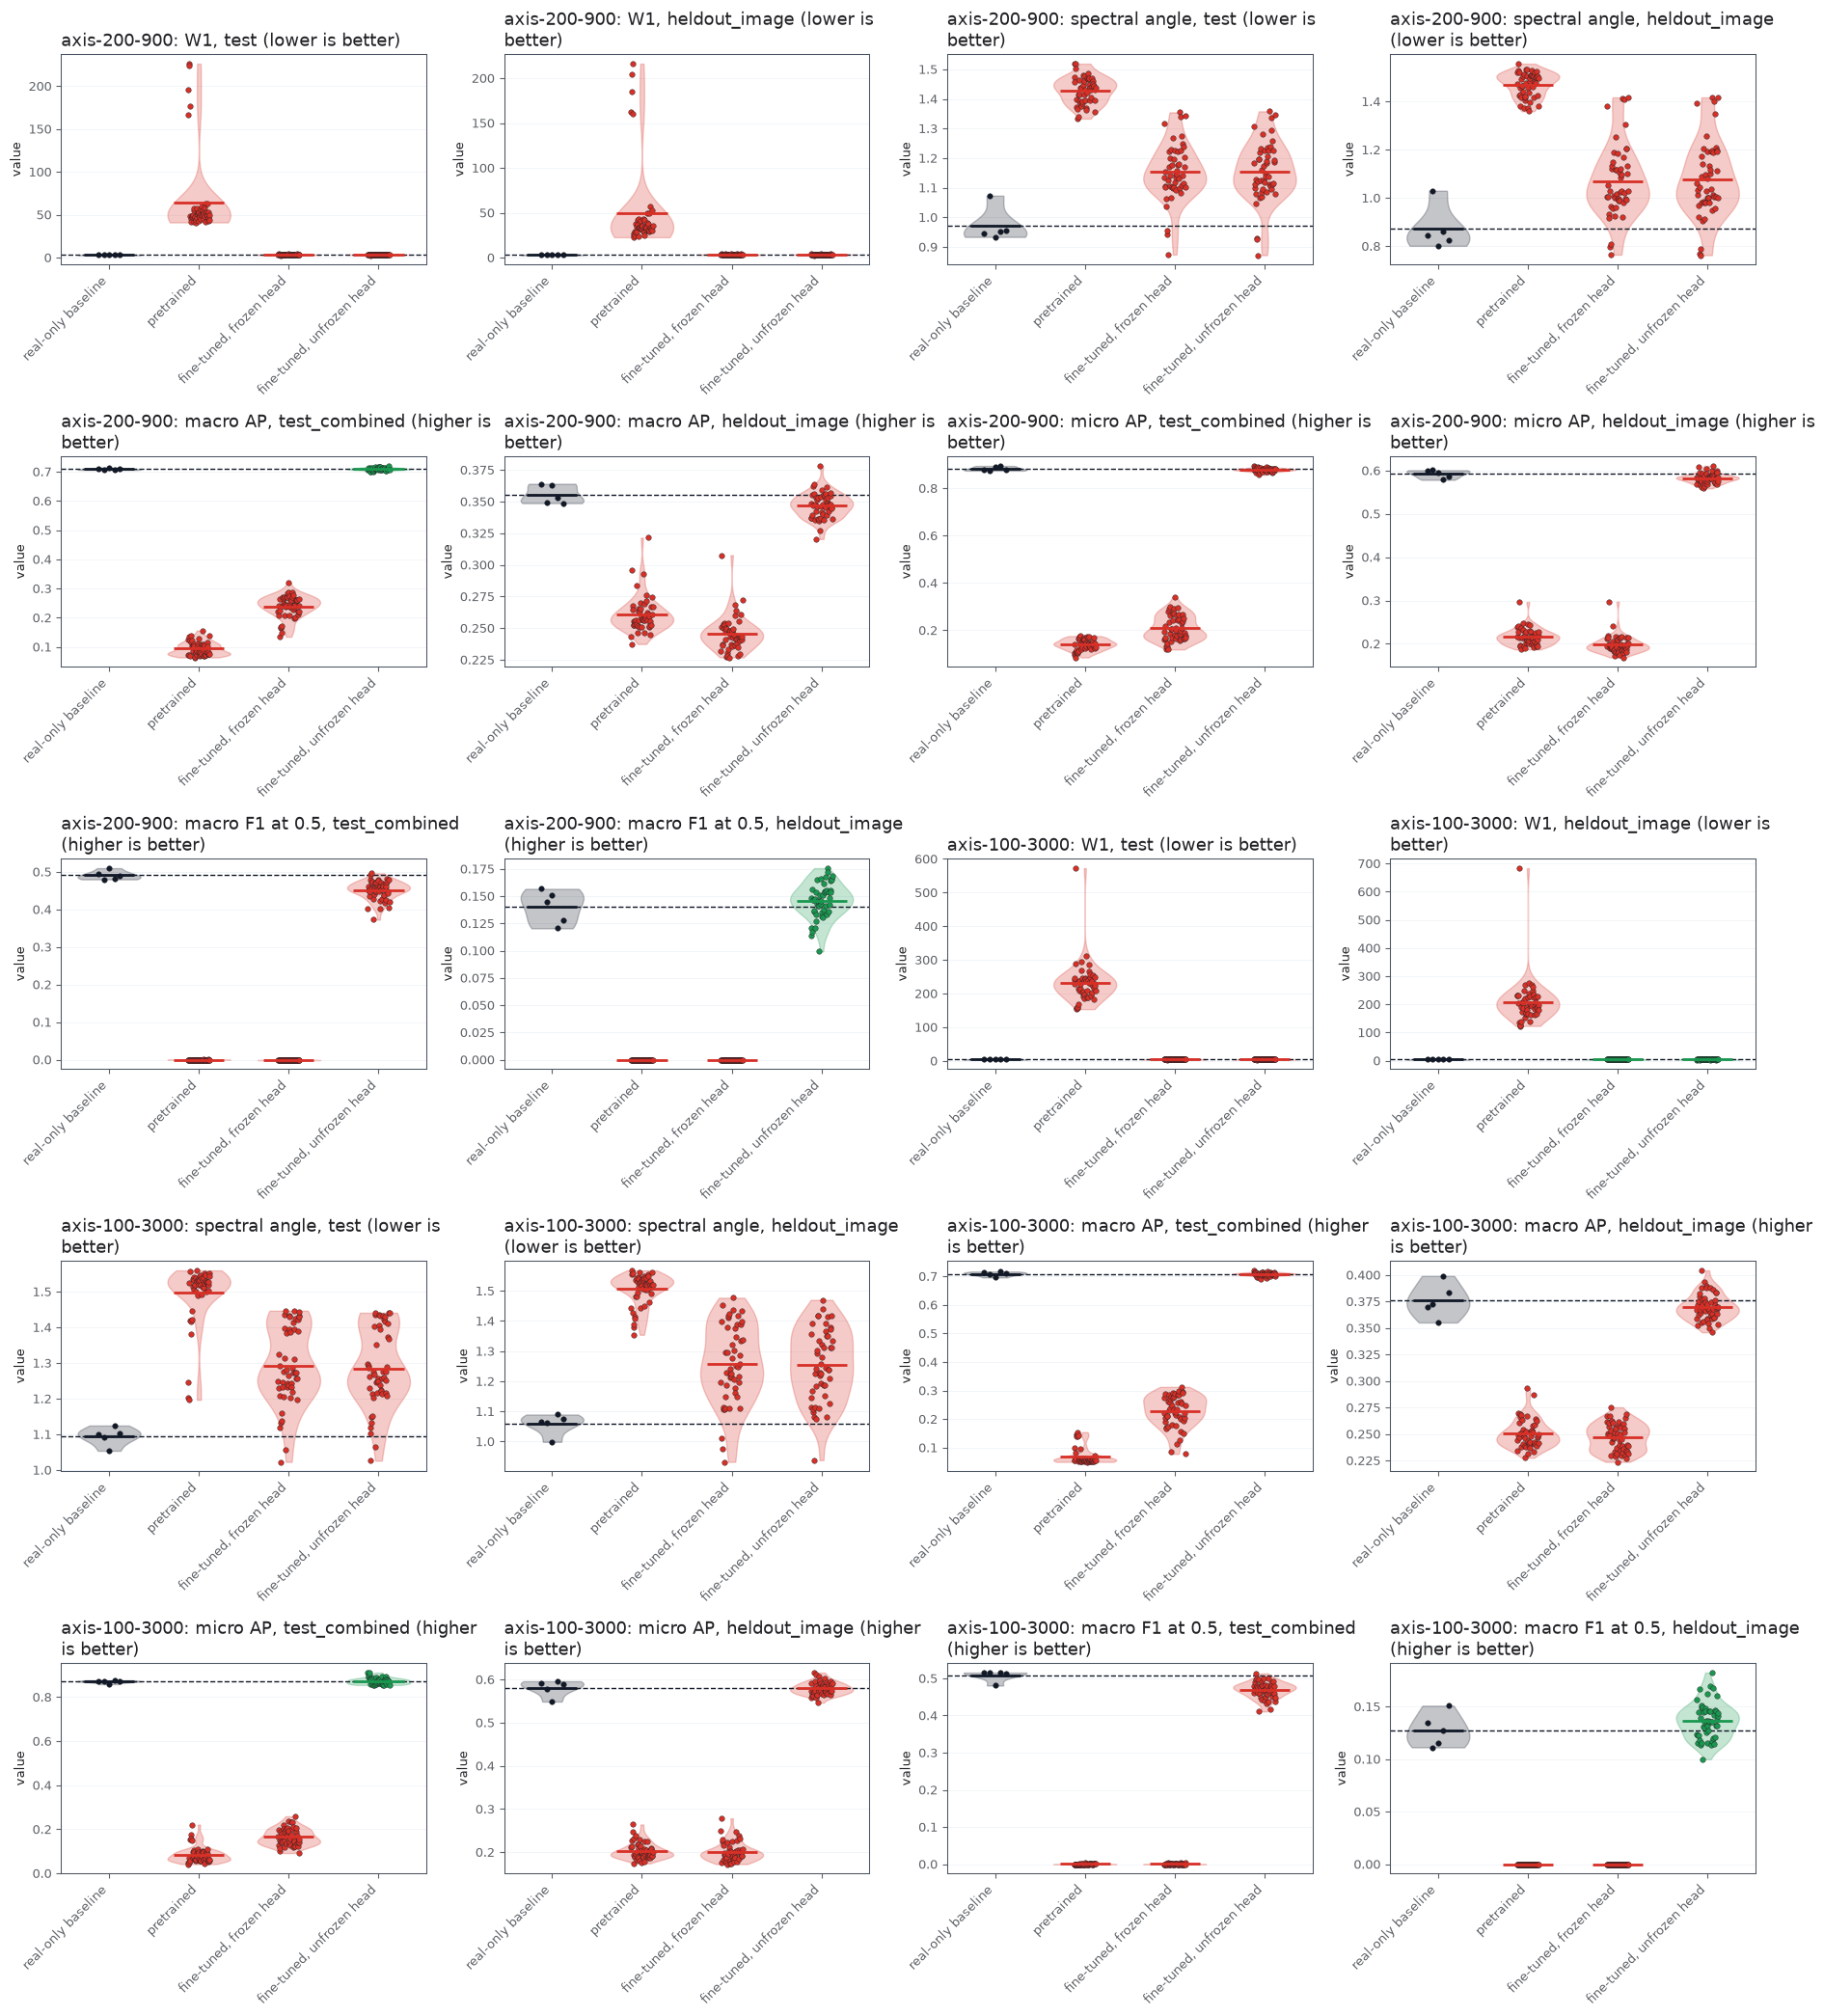

axis-200-900: W1, test


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,3.117 +/- 0.109,3.117 +/- 0.109,3.117 +/- 0.109
P0_single,197.775 +/- 26.938,3.479 +/- 0.409,3.486 +/- 0.119
P1_permutation,46.056 +/- 2.657,2.938 +/- 0.062,3.025 +/- 0.142
P2_joint_base,50.160 +/- 6.343,3.493 +/- 0.256,3.427 +/- 0.086
P2_staged_base,45.214 +/- 2.680,3.318 +/- 0.220,3.175 +/- 0.186
P3_joint_overlap,52.983 +/- 2.360,3.540 +/- 0.352,3.468 +/- 0.181
P3_staged_overlap,48.194 +/- 5.284,3.220 +/- 0.242,3.249 +/- 0.157
P4_joint_rare,53.377 +/- 4.432,3.424 +/- 0.221,3.490 +/- 0.224
P4_staged_rare,48.983 +/- 6.597,3.291 +/- 0.312,3.436 +/- 0.222


axis-200-900: W1, heldout_image


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,3.076 +/- 0.143,3.076 +/- 0.143,3.076 +/- 0.143
P0_single,185.632 +/- 24.787,3.715 +/- 0.525,3.678 +/- 0.191
P1_permutation,25.799 +/- 2.581,2.966 +/- 0.114,3.123 +/- 0.337
P2_joint_base,34.328 +/- 5.988,3.475 +/- 0.353,3.320 +/- 0.277
P2_staged_base,34.137 +/- 6.829,3.297 +/- 0.289,3.213 +/- 0.245
P3_joint_overlap,34.893 +/- 3.518,3.435 +/- 0.502,3.494 +/- 0.379
P3_staged_overlap,33.563 +/- 5.702,3.206 +/- 0.349,3.426 +/- 0.280
P4_joint_rare,33.484 +/- 6.357,3.482 +/- 0.332,3.382 +/- 0.086
P4_staged_rare,38.207 +/- 6.986,3.399 +/- 0.403,3.597 +/- 0.173


axis-200-900: spectral angle, test


...

stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.581 +/- 0.019,0.581 +/- 0.019,0.581 +/- 0.019
P0_single,0.233 +/- 0.023,0.232 +/- 0.038,0.571 +/- 0.013
P1_permutation,0.195 +/- 0.022,0.197 +/- 0.012,0.581 +/- 0.020
P2_joint_base,0.202 +/- 0.021,0.182 +/- 0.009,0.583 +/- 0.022
P2_staged_base,0.212 +/- 0.016,0.206 +/- 0.011,0.574 +/- 0.023
P3_joint_overlap,0.194 +/- 0.016,0.186 +/- 0.014,0.587 +/- 0.010
P3_staged_overlap,0.200 +/- 0.015,0.195 +/- 0.017,0.578 +/- 0.011
P4_joint_rare,0.196 +/- 0.011,0.201 +/- 0.027,0.582 +/- 0.013
P4_staged_rare,0.200 +/- 0.016,0.202 +/- 0.018,0.578 +/- 0.010


axis-100-3000: macro F1 at 0.5, test_combined


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.508 +/- 0.015,0.508 +/- 0.015,0.508 +/- 0.015
P0_single,0.000 +/- 0.000,0.000 +/- 0.000,0.475 +/- 0.011
P1_permutation,0.000 +/- 0.000,0.001 +/- 0.002,0.493 +/- 0.015
P2_joint_base,0.000 +/- 0.000,0.000 +/- 0.000,0.461 +/- 0.032
P2_staged_base,0.000 +/- 0.001,0.001 +/- 0.000,0.468 +/- 0.021
P3_joint_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.470 +/- 0.022
P3_staged_overlap,0.001 +/- 0.001,0.001 +/- 0.001,0.458 +/- 0.018
P4_joint_rare,0.000 +/- 0.001,0.000 +/- 0.000,0.470 +/- 0.023
P4_staged_rare,0.001 +/- 0.000,0.001 +/- 0.001,0.461 +/- 0.025


axis-100-3000: macro F1 at 0.5, heldout_image


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.128 +/- 0.016,0.128 +/- 0.016,0.128 +/- 0.016
P0_single,0.000 +/- 0.000,0.000 +/- 0.000,0.128 +/- 0.016
P1_permutation,0.000 +/- 0.000,0.000 +/- 0.000,0.137 +/- 0.022
P2_joint_base,0.000 +/- 0.000,0.000 +/- 0.000,0.133 +/- 0.024
P2_staged_base,0.000 +/- 0.000,0.000 +/- 0.000,0.138 +/- 0.008
P3_joint_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.137 +/- 0.018
P3_staged_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.135 +/- 0.007
P4_joint_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.140 +/- 0.020
P4_staged_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.140 +/- 0.032


In [4]:
frame_abs = table('model_values')

SELECTORS_ABS = [["axis-200-900: W1, test", {"axis": "axis-200-900", "family": "reconstruction", "metric": "masserstein", "evaluation": "test", "ranking": "none"}, "lower"], ["axis-200-900: W1, heldout_image", {"axis": "axis-200-900", "family": "reconstruction", "metric": "masserstein", "evaluation": "heldout_image", "ranking": "none"}, "lower"], ["axis-200-900: spectral angle, test", {"axis": "axis-200-900", "family": "reconstruction", "metric": "spectral_angle", "evaluation": "test", "ranking": "none"}, "lower"], ["axis-200-900: spectral angle, heldout_image", {"axis": "axis-200-900", "family": "reconstruction", "metric": "spectral_angle", "evaluation": "heldout_image", "ranking": "none"}, "lower"], ["axis-200-900: macro AP, test_combined", {"axis": "axis-200-900", "family": "prediction", "metric": "average_precision", "evaluation": "test_combined", "ranking": "annotation_retrieval"}, "higher"], ["axis-200-900: macro AP, heldout_image", {"axis": "axis-200-900", "family": "prediction", "metric": "average_precision", "evaluation": "heldout_image", "ranking": "annotation_retrieval"}, "higher"], ["axis-200-900: micro AP, test_combined", {"axis": "axis-200-900", "family": "prediction", "metric": "micro_average_precision", "evaluation": "test_combined", "ranking": "annotation_retrieval"}, "higher"], ["axis-200-900: micro AP, heldout_image", {"axis": "axis-200-900", "family": "prediction", "metric": "micro_average_precision", "evaluation": "heldout_image", "ranking": "annotation_retrieval"}, "higher"], ["axis-200-900: macro F1 at 0.5, test_combined", {"axis": "axis-200-900", "family": "prediction", "metric": "f1", "evaluation": "test_combined", "ranking": "annotation_retrieval"}, "higher"], ["axis-200-900: macro F1 at 0.5, heldout_image", {"axis": "axis-200-900", "family": "prediction", "metric": "f1", "evaluation": "heldout_image", "ranking": "annotation_retrieval"}, "higher"], ["axis-100-3000: W1, test", {"axis": "axis-100-3000", "family": "reconstruction", "metric": "masserstein", "evaluation": "test", "ranking": "none"}, "lower"], ["axis-100-3000: W1, heldout_image", {"axis": "axis-100-3000", "family": "reconstruction", "metric": "masserstein", "evaluation": "heldout_image", "ranking": "none"}, "lower"], ["axis-100-3000: spectral angle, test", {"axis": "axis-100-3000", "family": "reconstruction", "metric": "spectral_angle", "evaluation": "test", "ranking": "none"}, "lower"], ["axis-100-3000: spectral angle, heldout_image", {"axis": "axis-100-3000", "family": "reconstruction", "metric": "spectral_angle", "evaluation": "heldout_image", "ranking": "none"}, "lower"], ["axis-100-3000: macro AP, test_combined", {"axis": "axis-100-3000", "family": "prediction", "metric": "average_precision", "evaluation": "test_combined", "ranking": "annotation_retrieval"}, "higher"], ["axis-100-3000: macro AP, heldout_image", {"axis": "axis-100-3000", "family": "prediction", "metric": "average_precision", "evaluation": "heldout_image", "ranking": "annotation_retrieval"}, "higher"], ["axis-100-3000: micro AP, test_combined", {"axis": "axis-100-3000", "family": "prediction", "metric": "micro_average_precision", "evaluation": "test_combined", "ranking": "annotation_retrieval"}, "higher"], ["axis-100-3000: micro AP, heldout_image", {"axis": "axis-100-3000", "family": "prediction", "metric": "micro_average_precision", "evaluation": "heldout_image", "ranking": "annotation_retrieval"}, "higher"], ["axis-100-3000: macro F1 at 0.5, test_combined", {"axis": "axis-100-3000", "family": "prediction", "metric": "f1", "evaluation": "test_combined", "ranking": "annotation_retrieval"}, "higher"], ["axis-100-3000: macro F1 at 0.5, heldout_image", {"axis": "axis-100-3000", "family": "prediction", "metric": "f1", "evaluation": "heldout_image", "ranking": "annotation_retrieval"}, "higher"]]
STAGE_ORDER = ['real_only', *STAGES]
figures.metric_panels(frame_abs, panels=[(label, selector, direction) for label, selector, direction in SELECTORS_ABS], group='stage',
                      order=STAGE_ORDER, labels=STAGE_LABELS, baseline='real_only', columns=4, theme=theme);
plt.show()
for label, selector, direction in SELECTORS_ABS:
    rows = frame_abs
    for column, value in selector.items():
        rows = rows[rows[column] == value]
    base = rows[rows.stage == 'real_only']
    grid = pd.concat([rows[rows.stage != 'real_only'], *[base.assign(stage=stage) for stage in STAGES]])
    print(label)
    display(figures.comparison_table(grid, index='variant', columns='stage', baseline=BASELINE, order=ABS_ORDER,
                                     column_order=STAGES, direction={stage: direction for stage in STAGES}))

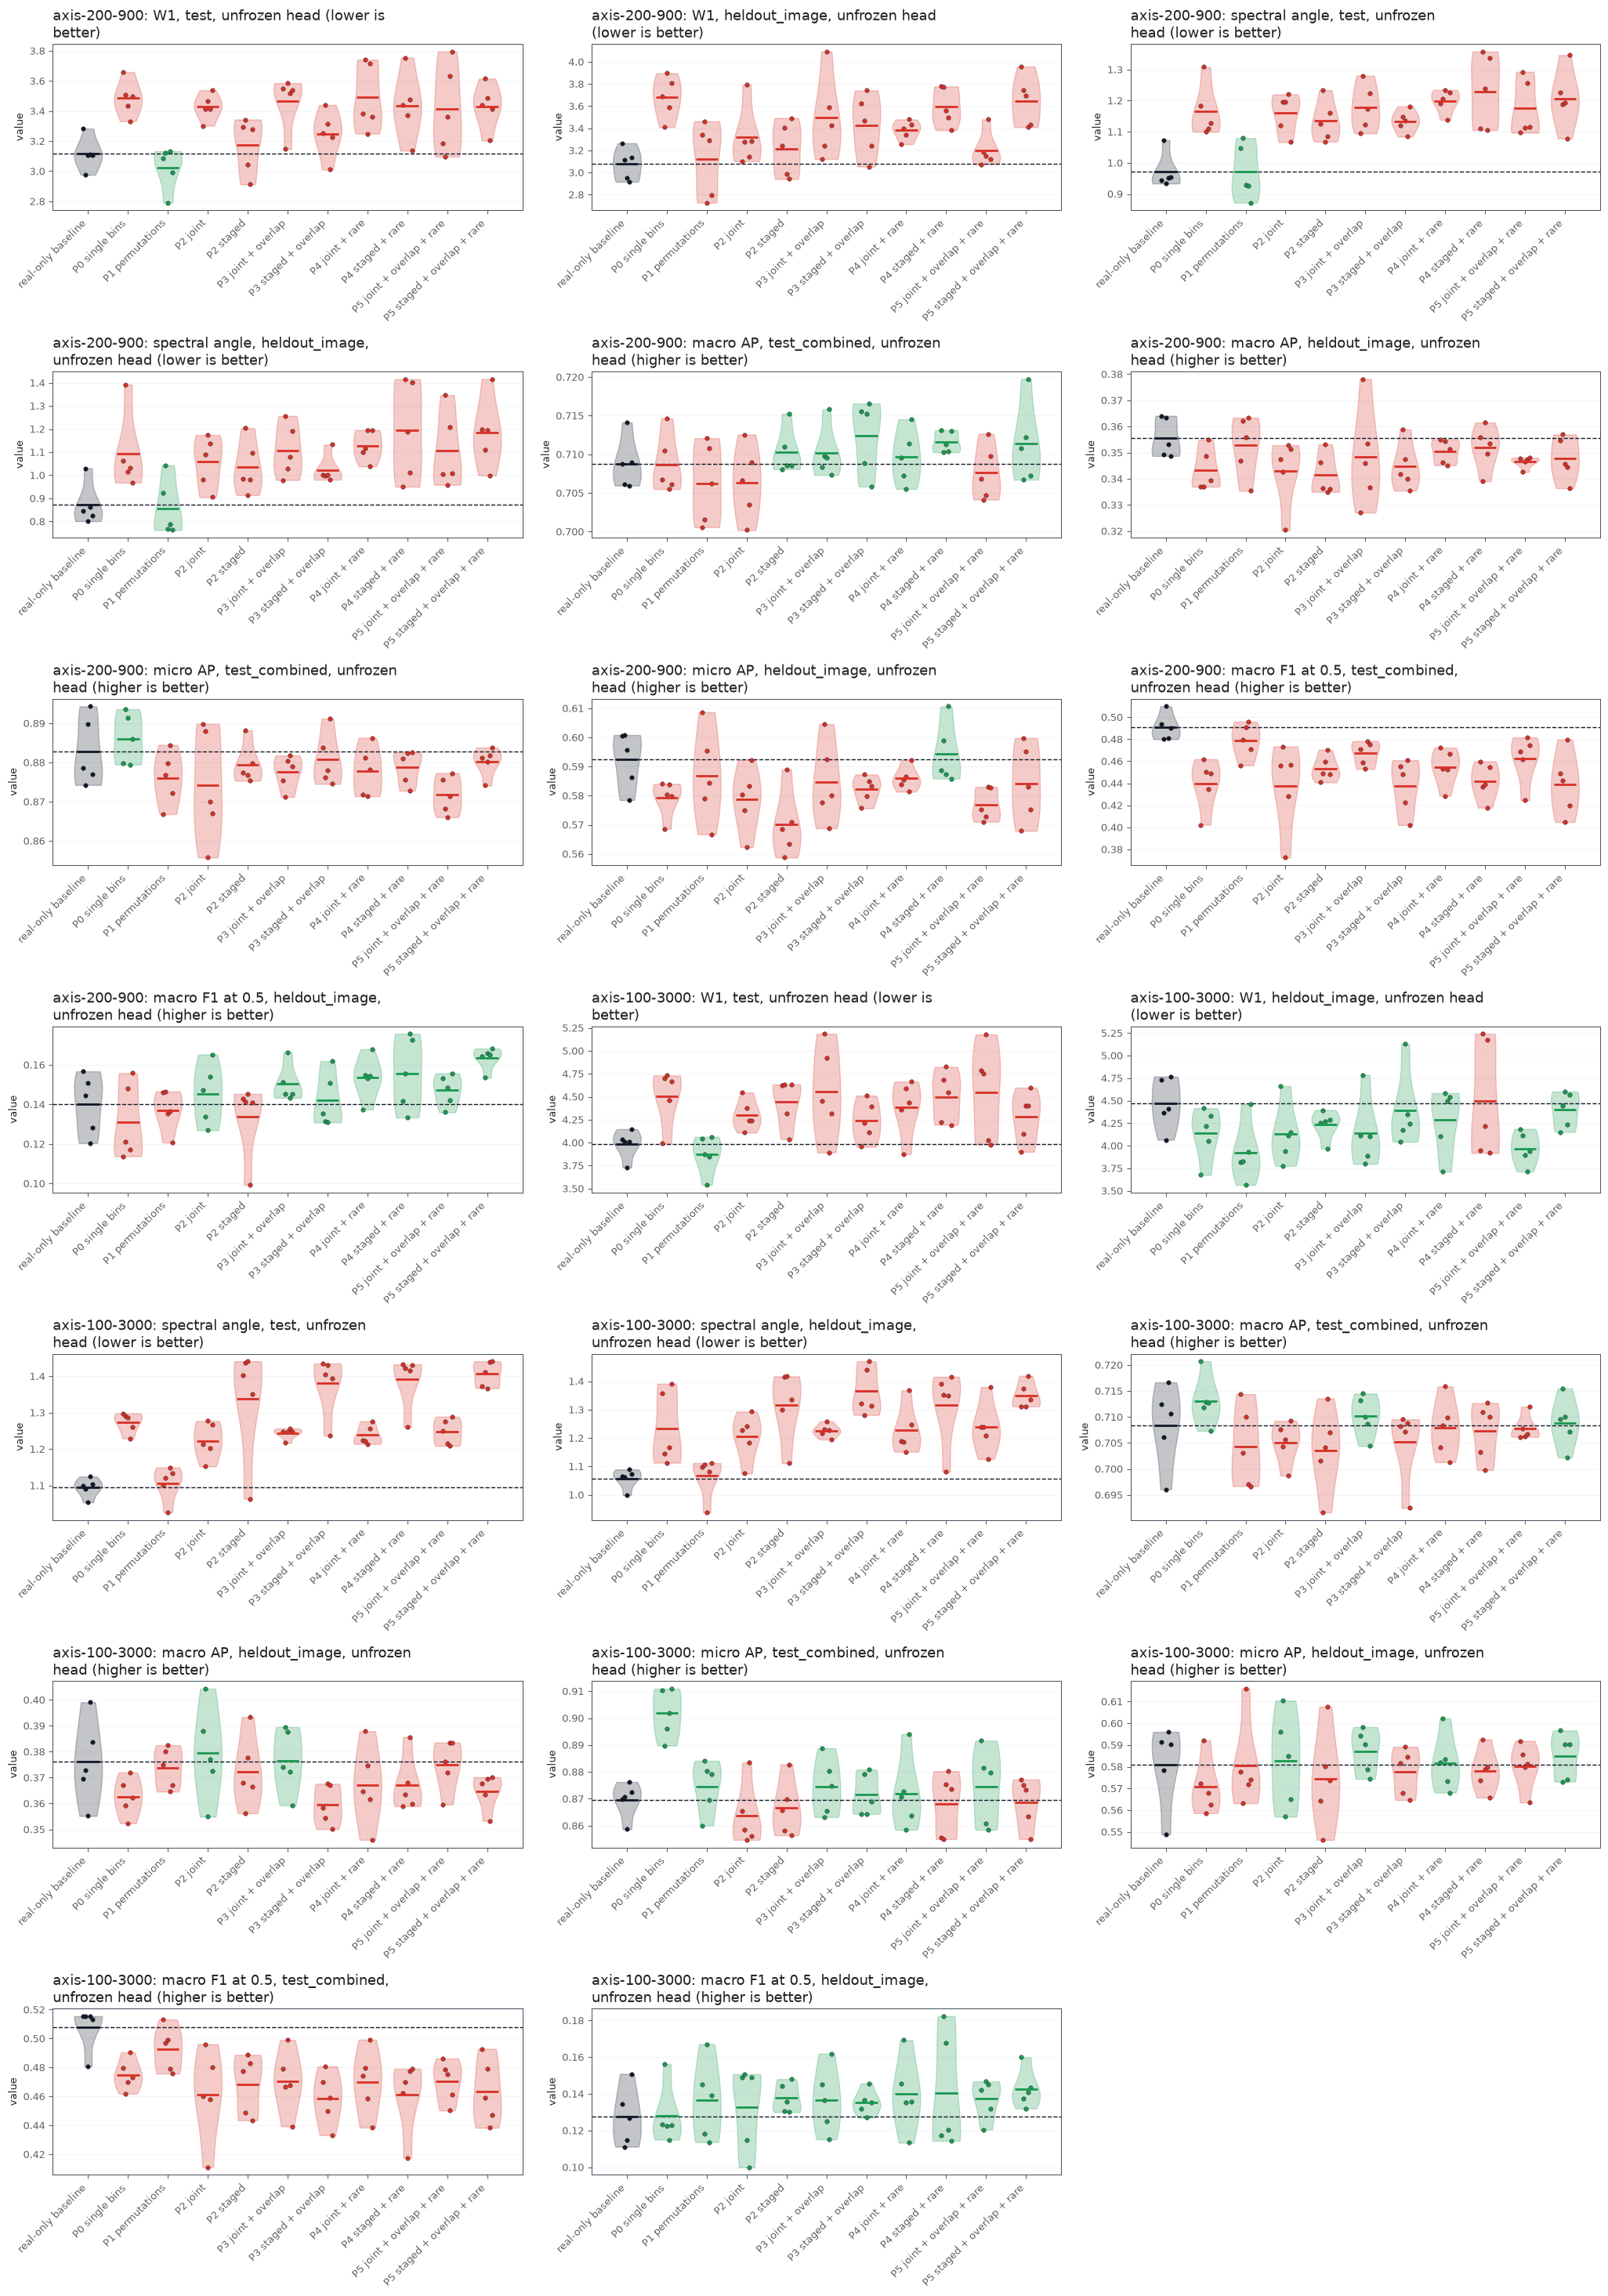

In [5]:
## Unfrozen-head stage per variant (the pooled figure above mixes variants with different effects)
unfrozen = frame_abs[frame_abs.stage.isin(['real_only', 'unfrozen_head'])] if 'frame_abs' in globals() else metrics_abs[metrics_abs.stage.isin(['real_only', 'unfrozen_head'])]
figures.metric_panels(unfrozen, panels=[(f'{label}, unfrozen head', selector, direction) for label, selector, direction in SELECTORS_ABS],
                      group='variant', order=ABS_ORDER, labels=LABELS_ABS, baseline=BASELINE, columns=3, theme=theme);

### Remarks

- axis-200-900: W1, test (by stage, variants pooled): baseline 3.117; others 3.36-64.55; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (3.36), worst pretrained (64.55).
- axis-200-900: W1, test (unfrozen head, per variant): baseline 3.117; others 3.025-3.49; 1 of 10 better than the baseline; best P1 permutations (3.025), worst P4 joint + rare (3.49).
  best single cell: P1 permutations, fine-tuned, frozen head (2.938 vs baseline 3.117).
- axis-200-900: W1, heldout_image (by stage, variants pooled): baseline 3.076; others 3.401-49.63; 0 of 3 better than the baseline; best fine-tuned, frozen head (3.401), worst pretrained (49.63).
- axis-200-900: W1, heldout_image (unfrozen head, per variant): baseline 3.076; others 3.123-3.678; 0 of 10 better than the baseline; best P1 permutations (3.123), worst P0 single bins (3.678).
  best single cell: P1 permutations, fine-tuned, frozen head (2.966 vs baseline 3.076).
- axis-200-900: spectral angle, test (by stage, variants pooled): baseline 0.9716; others 1.153-1.429; 0 of 3 better than the baseline; best fine-tuned, frozen head (1.153), worst pretrained (1.429).
- axis-200-900: spectral angle, test (unfrozen head, per variant): baseline 0.9716; others 0.9711-1.23; 1 of 10 better than the baseline; best P1 permutations (0.9711), worst P4 staged + rare (1.23).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.9711 vs baseline 0.9716).
- axis-200-900: spectral angle, heldout_image (by stage, variants pooled): baseline 0.8726; others 1.07-1.47; 0 of 3 better than the baseline; best fine-tuned, frozen head (1.07), worst pretrained (1.47).
- axis-200-900: spectral angle, heldout_image (unfrozen head, per variant): baseline 0.8726; others 0.8567-1.194; 1 of 10 better than the baseline; best P1 permutations (0.8567), worst P4 staged + rare (1.194).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.8567 vs baseline 0.8726).
- axis-200-900: macro AP, test_combined (by stage, variants pooled): baseline 0.7088; others 0.09429-0.7094; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7094), worst pretrained (0.09429).
- axis-200-900: macro AP, test_combined (unfrozen head, per variant): baseline 0.7088; others 0.7063-0.7124; 6 of 10 better than the baseline; best P3 staged + overlap (0.7124), worst P1 permutations (0.7063).
  best single cell: P3 staged + overlap, fine-tuned, unfrozen head (0.7124 vs baseline 0.7088).
- axis-200-900: macro AP, heldout_image (by stage, variants pooled): baseline 0.3557; others 0.2456-0.347; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.347), worst fine-tuned, frozen head (0.2456).
- axis-200-900: macro AP, heldout_image (unfrozen head, per variant): baseline 0.3557; others 0.3413-0.3527; 0 of 10 better than the baseline; best P1 permutations (0.3527), worst P2 staged (0.3413).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.3527 vs baseline 0.3557).
- axis-200-900: micro AP, test_combined (by stage, variants pooled): baseline 0.8828; others 0.1399-0.8783; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.8783), worst pretrained (0.1399).
- axis-200-900: micro AP, test_combined (unfrozen head, per variant): baseline 0.8828; others 0.8717-0.886; 1 of 10 better than the baseline; best P0 single bins (0.886), worst P5 joint + overlap + rare (0.8717).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.886 vs baseline 0.8828).
- axis-200-900: micro AP, heldout_image (by stage, variants pooled): baseline 0.5924; others 0.1977-0.5823; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.5823), worst fine-tuned, frozen head (0.1977).
- axis-200-900: micro AP, heldout_image (unfrozen head, per variant): baseline 0.5924; others 0.5701-0.5943; 1 of 10 better than the baseline; best P4 staged + rare (0.5943), worst P2 staged (0.5701).
  best single cell: P4 staged + rare, fine-tuned, unfrozen head (0.5943 vs baseline 0.5924).
- axis-200-900: macro F1 at 0.5, test_combined (by stage, variants pooled): baseline 0.4908; others 1.535e-07-0.4512; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.4512), worst fine-tuned, frozen head (1.535e-07).
- axis-200-900: macro F1 at 0.5, test_combined (unfrozen head, per variant): baseline 0.4908; others 0.4376-0.4787; 0 of 10 better than the baseline; best P1 permutations (0.4787), worst P2 joint (0.4376).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.4787 vs baseline 0.4908).
- axis-200-900: macro F1 at 0.5, heldout_image (by stage, variants pooled): baseline 0.1401; others 0-0.146; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.146), worst fine-tuned, frozen head (0).
- axis-200-900: macro F1 at 0.5, heldout_image (unfrozen head, per variant): baseline 0.1401; others 0.1312-0.1634; 7 of 10 better than the baseline; best P5 staged + overlap + rare (0.1634), worst P0 single bins (0.1312).
  best single cell: P5 staged + overlap + rare, fine-tuned, unfrozen head (0.1634 vs baseline 0.1401).
- axis-100-3000: W1, test (by stage, variants pooled): baseline 3.988; others 4.363-231.1; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (4.363), worst pretrained (231.1).
- axis-100-3000: W1, test (unfrozen head, per variant): baseline 3.988; others 3.873-4.554; 1 of 10 better than the baseline; best P1 permutations (3.873), worst P3 joint + overlap (4.554).
  best single cell: P1 permutations, fine-tuned, unfrozen head (3.873 vs baseline 3.988).
- axis-100-3000: W1, heldout_image (by stage, variants pooled): baseline 4.467; others 4.21-207.8; 2 of 3 better than the baseline; best fine-tuned, unfrozen head (4.21), worst pretrained (207.8).
- axis-100-3000: W1, heldout_image (unfrozen head, per variant): baseline 4.467; others 3.92-4.498; 9 of 10 better than the baseline; best P1 permutations (3.92), worst P4 staged + rare (4.498).
  best single cell: P1 permutations, fine-tuned, unfrozen head (3.92 vs baseline 4.467).
- axis-100-3000: spectral angle, test (by stage, variants pooled): baseline 1.094; others 1.285-1.497; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (1.285), worst pretrained (1.497).
- axis-100-3000: spectral angle, test (unfrozen head, per variant): baseline 1.094; others 1.106-1.406; 0 of 10 better than the baseline; best P1 permutations (1.106), worst P5 staged + overlap + rare (1.406).
  best single cell: P1 permutations, fine-tuned, unfrozen head (1.106 vs baseline 1.094).
- axis-100-3000: spectral angle, heldout_image (by stage, variants pooled): baseline 1.058; others 1.255-1.506; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (1.255), worst pretrained (1.506).
- axis-100-3000: spectral angle, heldout_image (unfrozen head, per variant): baseline 1.058; others 1.067-1.366; 0 of 10 better than the baseline; best P1 permutations (1.067), worst P3 staged + overlap (1.366).
  best single cell: P1 permutations, fine-tuned, unfrozen head (1.067 vs baseline 1.058).
- axis-100-3000: macro AP, test_combined (by stage, variants pooled): baseline 0.7084; others 0.06737-0.7073; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7073), worst pretrained (0.06737).
- axis-100-3000: macro AP, test_combined (unfrozen head, per variant): baseline 0.7084; others 0.7036-0.7131; 3 of 10 better than the baseline; best P0 single bins (0.7131), worst P2 staged (0.7036).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.7131 vs baseline 0.7084).
- axis-100-3000: macro AP, heldout_image (by stage, variants pooled): baseline 0.3761; others 0.2471-0.3698; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.3698), worst fine-tuned, frozen head (0.2471).
- axis-100-3000: macro AP, heldout_image (unfrozen head, per variant): baseline 0.3761; others 0.3595-0.3794; 2 of 10 better than the baseline; best P2 joint (0.3794), worst P3 staged + overlap (0.3595).
  best single cell: P2 joint, fine-tuned, unfrozen head (0.3794 vs baseline 0.3761).
- axis-100-3000: micro AP, test_combined (by stage, variants pooled): baseline 0.8696; others 0.0841-0.8736; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.8736), worst pretrained (0.0841).
- axis-100-3000: micro AP, test_combined (unfrozen head, per variant): baseline 0.8696; others 0.8637-0.9018; 6 of 10 better than the baseline; best P0 single bins (0.9018), worst P2 joint (0.8637).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.9018 vs baseline 0.8696).
- axis-100-3000: micro AP, heldout_image (by stage, variants pooled): baseline 0.5809; others 0.201-0.5798; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.5798), worst fine-tuned, frozen head (0.201).
- axis-100-3000: micro AP, heldout_image (unfrozen head, per variant): baseline 0.5809; others 0.5706-0.5872; 4 of 10 better than the baseline; best P3 joint + overlap (0.5872), worst P0 single bins (0.5706).
  best single cell: P3 joint + overlap, fine-tuned, unfrozen head (0.5872 vs baseline 0.5809).
- axis-100-3000: macro F1 at 0.5, test_combined (by stage, variants pooled): baseline 0.508; others 0.0004628-0.4691; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.4691), worst pretrained (0.0004628).
- axis-100-3000: macro F1 at 0.5, test_combined (unfrozen head, per variant): baseline 0.508; others 0.4585-0.4927; 0 of 10 better than the baseline; best P1 permutations (0.4927), worst P3 staged + overlap (0.4585).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.4927 vs baseline 0.508).
- axis-100-3000: macro F1 at 0.5, heldout_image (by stage, variants pooled): baseline 0.1276; others 0-0.1367; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.1367), worst fine-tuned, frozen head (0).
- axis-100-3000: macro F1 at 0.5, heldout_image (unfrozen head, per variant): baseline 0.1276; others 0.128-0.1427; 10 of 10 better than the baseline; best P5 staged + overlap + rare (0.1427), worst P0 single bins (0.128).
  best single cell: P5 staged + overlap + rare, fine-tuned, unfrozen head (0.1427 vs baseline 0.1276).

### Notes

## Verdict counts per axis and stage

### Methodology

#### Theoretical

How many variant x metric x evaluation cells improve, worsen or are inconclusive.

#### Implementation

`verdict`.

#### Figure descriptions

No figure.

In [6]:
display(verdict.groupby(['axis', 'stage', 'verdict']).size().unstack(fill_value=0).reindex(columns=['improves', 'inconclusive', 'worsens']))

verdict                      improves  inconclusive  worsens
axis          stage                                         
axis-100-3000 frozen_head           1            15      114
              pretrained            0             0      130
              unfrozen_head         6            94       30
axis-200-900  frozen_head           1            17      112
              pretrained            0             0      130
              unfrozen_head         1            86       43

### Remarks

- axis-100-3000, frozen head: 1 improve, 15 inconclusive, 114 worsen (of 130).
- axis-100-3000, pretrained: 0 improve, 0 inconclusive, 130 worsen (of 130).
- axis-100-3000, unfrozen head: 6 improve, 94 inconclusive, 30 worsen (of 130).
- axis-200-900, frozen head: 1 improve, 17 inconclusive, 112 worsen (of 130).
- axis-200-900, pretrained: 0 improve, 0 inconclusive, 130 worsen (of 130).
- axis-200-900, unfrozen head: 1 improve, 86 inconclusive, 43 worsen (of 130).

### Notes

## Verdict map

### Methodology

#### Theoretical

The label of every variant, key metric and evaluation.

#### Implementation

`verdict`, coded worsens = -1, inconclusive = 0, improves = 1.

#### Figure descriptions

One heat map per axis and stage: rows = variants, columns = metric | evaluation; red = worsens, blue = improves (annotated with the mean improvement).

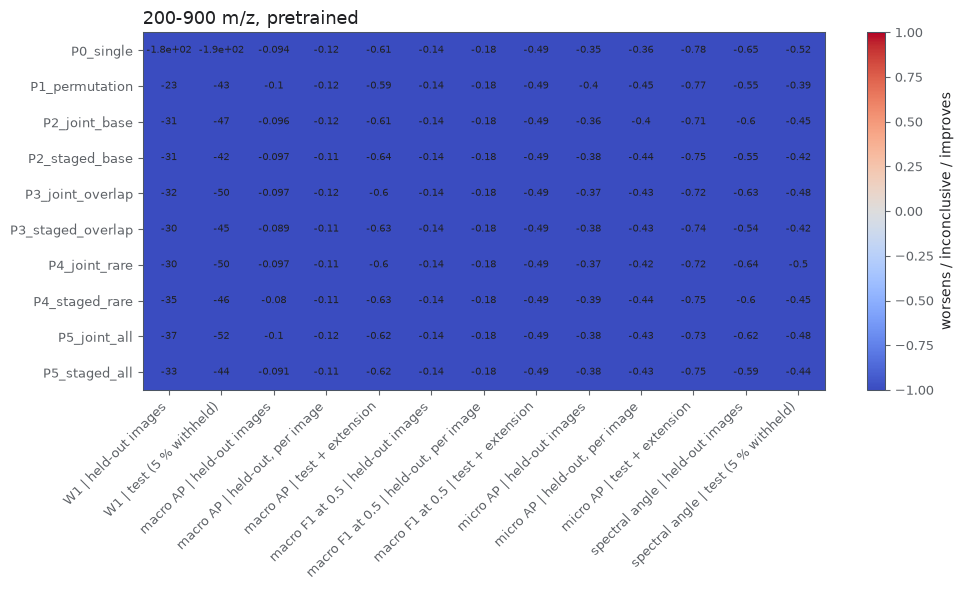

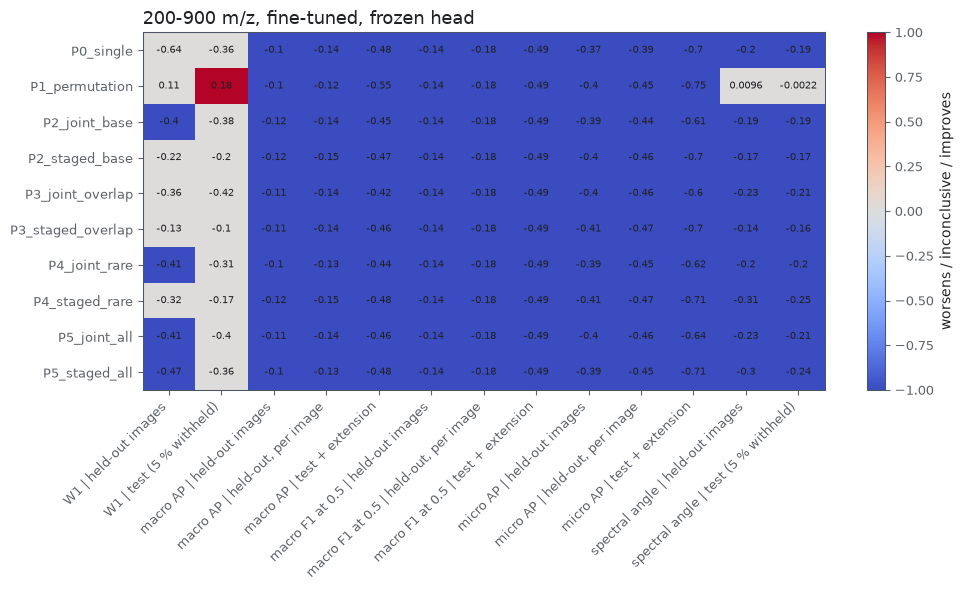

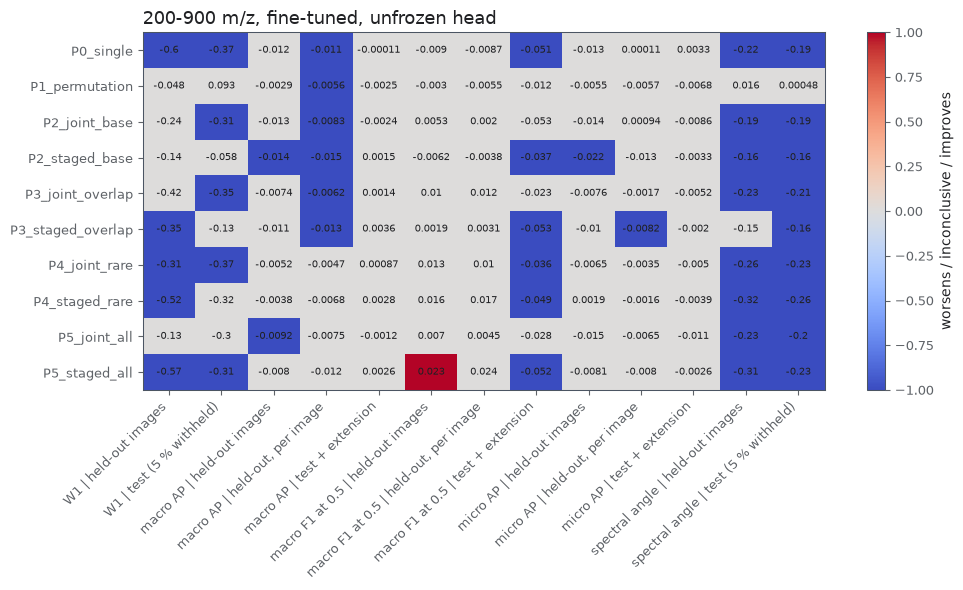

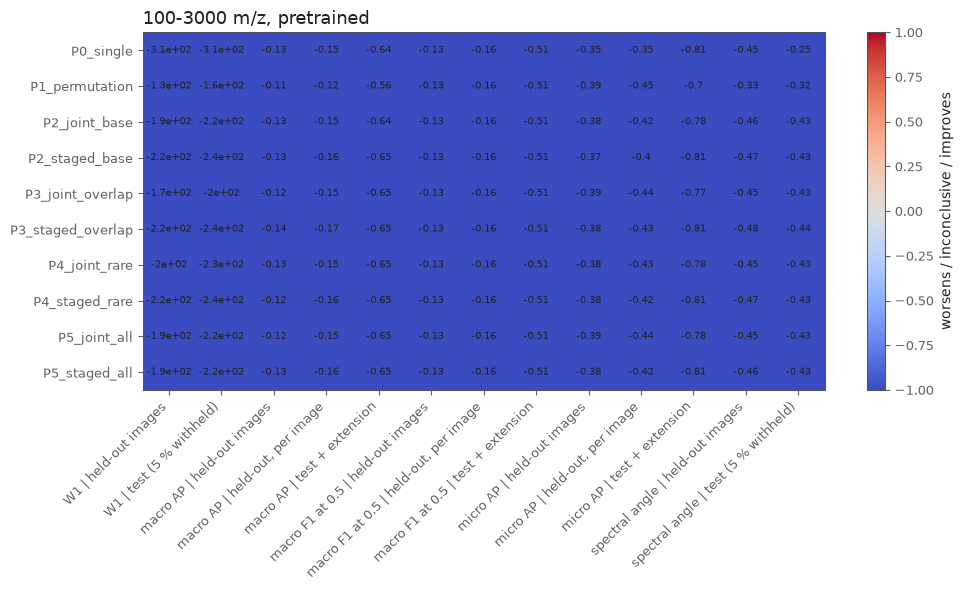

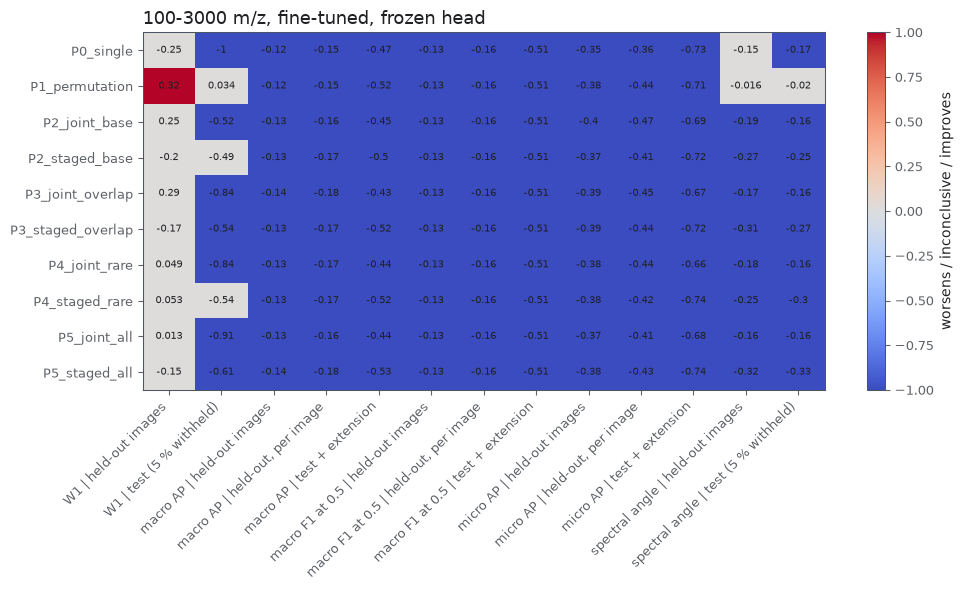

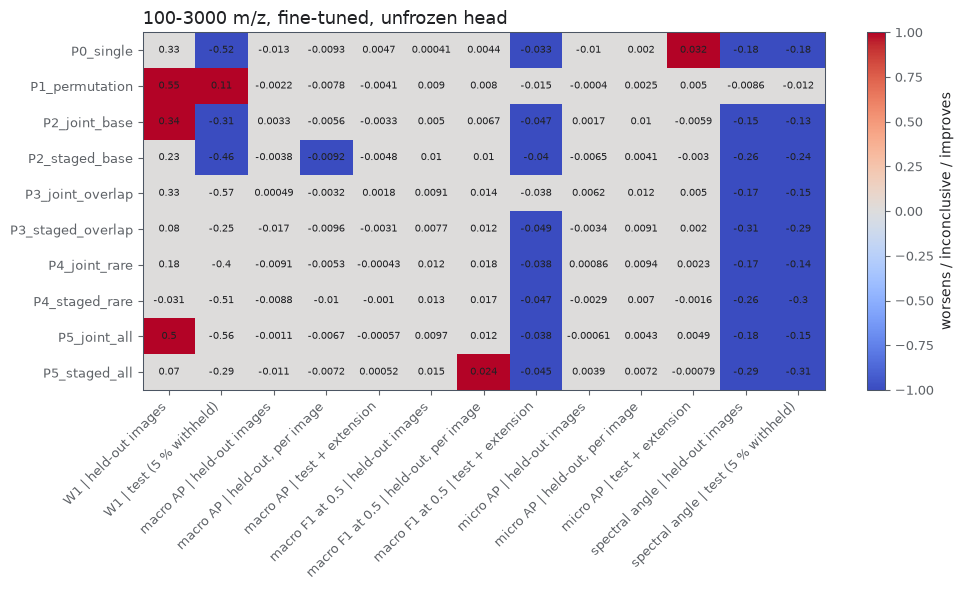

In [7]:
for axis in AXES:
    for stage in STAGES:
        rows = verdict[(verdict.axis == axis) & (verdict.stage == stage)]
        matrix = rows.pivot_table(index='variant', columns='column', values='verdict', aggfunc='first').map(CODES.get).reindex(VARIANTS)
        figure = figures.matrix_heatmap(matrix.astype(float), title=f'{AXIS_LABELS[axis]}, {STAGE_LABELS[stage]}', colorbar_label='worsens / inconclusive / improves',
                                        diverging=True, theme=theme)
        means = rows.pivot_table(index='variant', columns='column', values='mean').reindex(VARIANTS)[matrix.columns]
        ax = figure.axes[0]
        for (row, column), value in np.ndenumerate(means.to_numpy(float)):
            ax.text(column, row, f'{value:.2g}', ha='center', va='center', fontsize=7)
        plt.show()

### Remarks

- Pretrained: every cell worsens on both axes. Frozen head: head metrics worsen everywhere; reconstruction is mostly worse or inconclusive. Unfrozen head: mostly inconclusive; the worsening cells are the spectral angle (every variant except P1) and F1 at 0.5 on test + extension.

### Notes

## The fine-tuned (unfrozen-head) variants in detail

### Methodology

#### Theoretical

The unfrozen-head stage is the only stage in which the head can adapt to real data; it is the stage in which
the thesis can be accepted. The table gives the interval strings.

#### Implementation

`verdict` rows of the unfrozen stage.

#### Figure descriptions

No figure.

In [8]:
rows = verdict[verdict.stage == 'unfrozen_head']
display(rows.assign(result=interval(rows) + ' ' + rows.verdict.str[:3]).pivot_table(index=['axis', 'variant'], columns='column', values='result', aggfunc='first'))

column                                           W1 | held-out images               W1 | test (5 % withheld)                macro AP | held-out images             macro AP | held-out, per image  \
axis          variant                                                                                                                                                                               
axis-100-3000 P0_single             0.329 [-0.266, 0.925] (+3/-2) inc   -0.521 [-0.999, -0.0437] (+1/-4) wor   -0.0135 [-0.0271, 0.000178] (+0/-5) inc    -0.00925 [-0.0214, 0.00291] (+1/-4) inc   
              P1_permutation         0.548 [0.271, 0.825] (+5/-0) imp      0.115 [0.0201, 0.209] (+4/-1) imp    -0.00222 [-0.0318, 0.0273] (+3/-2) inc    -0.00779 [-0.0198, 0.00416] (+1/-4) inc   
              P2_joint_base         0.338 [0.0212, 0.656] (+5/-0) imp  -0.314 [-0.625, -0.00378] (+0/-5) wor     0.00329 [-0.0236, 0.0302] (+2/-3) inc     -0.0056 [-0.0124, 0.00124] (+0/-5) inc   
              P2_staged_base        0.233 [-0.175, 0.641] (+3/-2) inc    -0.461 [-0.771, -0.151] (+0/-5) wor    -0.00377 [-0.0238, 0.0163] (+1/-4) inc    -0.0092 [-0.0165, -0.00194] (+1/-4) wor   
              P3_joint_overlap       0.33 [-0.226, 0.885] (+4/-1) inc       -0.566 [-1.3, 0.172] (+1/-4) inc    0.000485 [-0.0316, 0.0325] (+3/-2) inc    -0.00316 [-0.0157, 0.00934] (+2/-3) inc   
              P3_staged_overlap    0.0799 [-0.773, 0.933] (+4/-1) inc      -0.25 [-0.653, 0.153] (+1/-4) inc    -0.0166 [-0.0398, 0.00664] (+1/-4) inc     -0.00961 [-0.0304, 0.0112] (+1/-4) inc   
              P4_joint_rare          0.18 [-0.438, 0.799] (+3/-2) inc    -0.396 [-0.845, 0.0522] (+1/-4) inc    -0.00907 [-0.0433, 0.0251] (+2/-3) inc     -0.00526 [-0.0216, 0.0111] (+3/-2) inc   
              P4_staged_rare       -0.0307 [-1.05, 0.993] (+2/-3) inc     -0.507 [-1.02, 0.0093] (+0/-5) inc   -0.00885 [-0.0255, 0.00781] (+1/-4) inc     -0.0103 [-0.0225, 0.00187] (+1/-4) inc   
              P5_joint_all           0.499 [0.151, 0.847] (+5/-0) imp      -0.557 [-1.36, 0.249] (+1/-4) inc     -0.0011 [-0.0167, 0.0145] (+2/-3) inc     -0.00674 [-0.0149, 0.0014] (+1/-4) inc   
              P5_staged_all        0.0697 [-0.441, 0.581] (+3/-2) inc     -0.292 [-0.688, 0.105] (+1/-4) inc     -0.0113 [-0.0386, 0.0161] (+1/-4) inc    -0.00717 [-0.0184, 0.00407] (+1/-4) inc   
axis-200-900  P0_single           -0.602 [-0.917, -0.287] (+0/-5) wor    -0.369 [-0.509, -0.228] (+0/-5) wor   -0.0123 [-0.0252, 0.000566] (+1/-4) inc    -0.0107 [-0.0175, -0.00385] (+0/-5) wor   
              P1_permutation      -0.0477 [-0.449, 0.353] (+2/-3) inc     0.0925 [-0.132, 0.317] (+3/-2) inc    -0.00295 [-0.0201, 0.0142] (+2/-3) inc   -0.0056 [-0.00785, -0.00335] (+0/-5) wor   
              P2_joint_base        -0.244 [-0.701, 0.213] (+1/-4) inc    -0.31 [-0.524, -0.0959] (+0/-5) wor       -0.0128 [-0.0356, 0.01] (+1/-4) inc  -0.00831 [-0.0161, -0.000538] (+1/-4) wor   
              P2_staged_base      -0.137 [-0.352, 0.0776] (+1/-4) inc    -0.0576 [-0.329, 0.214] (+2/-3) inc      -0.0143 [-0.0187, -0.01] (+0/-5) wor    -0.0146 [-0.0281, -0.00112] (+0/-5) wor   
              P3_joint_overlap      -0.419 [-1.04, 0.204] (+1/-4) inc     -0.35 [-0.509, -0.192] (+0/-5) wor    -0.00737 [-0.0376, 0.0229] (+2/-3) inc  -0.00623 [-0.0115, -0.000949] (+0/-5) wor   
              P3_staged_overlap   -0.351 [-0.69, -0.0111] (+0/-5) wor     -0.131 [-0.407, 0.144] (+2/-3) inc     -0.011 [-0.0261, 0.00406] (+1/-4) inc    -0.0129 [-0.0212, -0.00468] (+0/-5) wor   
              P4_joint_rare      -0.306 [-0.565, -0.0473] (+1/-4) wor   -0.373 [-0.74, -0.00593] (+0/-5) wor   -0.00519 [-0.0115, 0.00114] (+1/-4) inc   -0.00474 [-0.0101, 0.000624] (+0/-5) inc   
              P4_staged_rare      -0.522 [-0.721, -0.322] (+0/-5) wor    -0.319 [-0.674, 0.0363] (+0/-5) inc     -0.0038 [-0.011, 0.00343] (+1/-4) inc      -0.00676 [-0.02, 0.00647] (+1/-4) inc   
              P5_joint_all         -0.126 [-0.477, 0.224] (+

### Remarks

- Every `improves` cell: axis-200-900 frozen head P1 permutations W1 test 0.179 [0.0533, 0.306]; axis-200-900 unfrozen head P5 staged + overlap + rare macro F1@0.5 held-out 0.0233 [0.00137, 0.0453]; axis-100-3000 unfrozen head P0 single bins micro AP test+ext 0.0322 [0.0205, 0.0439]; axis-100-3000 frozen head P1 permutations W1 held-out 0.317 [0.118, 0.517]; axis-100-3000 unfrozen head P1 permutations W1 test 0.115 [0.0201, 0.209]; axis-100-3000 unfrozen head P1 permutations W1 held-out 0.548 [0.271, 0.825]; axis-100-3000 unfrozen head P2 joint W1 held-out 0.338 [0.0212, 0.656]; axis-100-3000 unfrozen head P5 joint + overlap + rare W1 held-out 0.499 [0.151, 0.847]; axis-100-3000 unfrozen head P5 staged + overlap + rare macro F1@0.5 held-out per image 0.0244 [0.00811, 0.0407].

### Notes

## Targeted mechanisms against their matched controls

### Methodology

#### Theoretical

Rare quota: macro AP over the rare classes, variant with minus without the quota. Overlap quota: macro AP over
the overlap classes, with minus without.

#### Implementation

`targeted`.

#### Figure descriptions

No figure.

In [9]:
display(targeted.assign(result=interval(targeted)).pivot_table(index=['mechanism', 'axis', 'variant', 'control'], columns='stage', values=['result', 'verdict'], aggfunc='first'))

result                                                                                  verdict  \
stage                                                                               frozen_head                          pretrained                          unfrozen_head   frozen_head   
mechanism axis          variant           control                                                                                                                                          
overlap   axis-100-3000 P3_joint_overlap  P2_joint_base          0.0602 [-0.083, 0.203] (+3/-2)  0.00834 [-0.00879, 0.0255] (+4/-1)       0.00733 [-0.0333, 0.048] (+3/-2)  inconclusive   
                        P3_staged_overlap P2_staged_base        0.0342 [-0.0197, 0.088] (+3/-2)    -0.0127 [-0.069, 0.0436] (+4/-1)      0.00201 [-0.0301, 0.0341] (+2/-3)  inconclusive   
                        P5_joint_all      P4_joint_rare         -0.0109 [-0.179, 0.157] (+1/-4)    0.00686 [-0.0613, 0.075] (+4/-1)       0.0156 [-0.0167, 0.0479] (+3/-2)  inconclusive   
                        P5_staged_all     P4_staged_rare         -0.0257 [-0.17, 0.119] (+2/-3)  -0.00767 [-0.0445, 0.0291] (+2/-3)   -0.00181 [-0.00789, 0.00428] (+1/-4)  inconclusive   
          axis-200-900  P3_joint_overlap  P2_joint_base           0.0253 [-0.119, 0.17] (+2/-3)     -0.0487 [-0.14, 0.0429] (+1/-4)    0.00211 [-0.00357, 0.00778] (+4/-1)  inconclusive   
                        P3_staged_overlap P2_staged_base        0.0358 [-0.0732, 0.145] (+3/-2)     0.0186 [-0.0653, 0.102] (+3/-2)  -0.000474 [-0.00717, 0.00623] (+4/-1)  inconclusive   
                        P5_joint_all      P4_joint_rare       -0.0131 [-0.0783, 0.0521] (+2/-3)     0.0326 [-0.0791, 0.144] (+4/-1)   -0.00232 [-0.00649, 0.00184] (+1/-4)  inconclusive   
                        P5_staged_all     P4_staged_rare          0.0124 [-0.155, 0.18] (+2/-3)   0.00911 [-0.0502, 0.0684] (+4/-1)     0.00231 [-0.00258, 0.0072] (+3/-2)  inconclusive   
rare      axis-100-3000 P4_joint_rare     P2_joint_base        0.0288 [-0.0371, 0.0947] (+3/-2)   0.00413 [-0.0155, 0.0238] (+4/-1)     -0.00159 [-0.0173, 0.0141] (+3/-2)  inconclusive   
                        P4_staged_rare    P2_staged_base     -0.0236 [-0.0551, 0.00798] (+1/-4)   0.00221 [-0.0162, 0.0206] (+2/-3)      0.00292 [-0.0141, 0.0199] (+3/-2)  inconclusive   
                        P5_joint_all      P3_joint_overlap      -0.018 [-0.127, 0.0912] (+2/-3)   0.00192 [-0.0449, 0.0487] (+1/-4)   -0.00209 [-0.00625, 0.00207] (+1/-4)  inconclusive   
                        P5_staged_all     P3_staged_overlap  -0.0619 [-0.115, -0.00844] (+1/-4)    0.00504 [-0.0159, 0.026] (+3/-2)    -0.000165 [-0.0131, 0.0127] (+3/-2)       worsens   
          axis-200-900  P4_joint_rare     P2_joint_base         0.0396 [0.0081, 0.0712] (+5/-0)  -0.00299 [-0.0304, 0.0244] (+3/-2)     0.0011 [-0.00602, 0.00823] (+3/-2)      improves   
                        P4_staged_rare    P2_staged_base        -0.02 [-0.0633, 0.0232] (+1/-4)    0.0126 [-0.0155, 0.0408] (+4/-1)     -0.00321 [-0.0127, 0.0063] (+1/-4)  inconclusive   
                        P5_joint_all      P3_joint_overlap     -0.018 [-0.0601, 0.0241] (+2/-3)   -0.0135 [-0.0664, 0.0394] (+1/-4)    -0.00492 [-0.0187, 0.00886] (+1/-4)  inconclusive   
                        P5_staged_all     P3_staged_overlap  -0.00945 [-0.0513, 0.0324] (+2/-3)    -0.0034 [-0.019, 0.0122] (+1/-4)    7.46e-06 [-0.0053, 0.00532] (+4/-1)  inconclusive   

                                                                                         
stage                                                          pretrained unfrozen_head  
mechanism axis          variant           control                                        
overlap   axis-100-3000 P3_joint_overlap  P2_joint_base      inconclusive  inconclusive  
                        P3_staged_overlap P2_staged_base     inconclusive  inconclusive  
                        P5_joint_all      P4_joint_rare      incon

### Remarks

- rare, axis-200-900, frozen head, P4 joint + rare - P2 joint: 0.0396 [0.0081, 0.0712] (improves)
- rare, axis-100-3000, frozen head, P5 staged + overlap + rare - P3 staged + overlap: -0.0619 [-0.115, -0.00844] (worsens)
- 46 of 48 targeted cells are inconclusive.

### Notes

## Results / Summary

### LLM

- **Observed:** of 780 variant x stage x key-metric cells, 9 improve on the baseline, 559 worsen and 212 are inconclusive. The pretrained and frozen-head stages worsen almost everything; the unfrozen stage is mostly inconclusive (86 / 94 of 130 cells), with worse spectral angle for every variant except P1 and a few isolated improvements, the only repeated one being the held-out W1 on 100-3000 (P1, P2 joint, P5 joint).
- **Observed:** the targeted mechanisms are inconclusive in 46 of 48 matched cells (one positive, one negative, both at the frozen stage).
- **Interpretation:** at 10 real epochs the thesis that synthetic pretraining improves on the real-only baseline is **not supported** for the head and for the narrow axis; it is **weakly supported** for the reconstruction of new images on the wide axis, with P1 permutations (no single-bin spectra) as the only variant without a significant shape penalty. The learning curves (0_06) show no faster convergence of the pretrained starts, so a benefit of a longer run is neither shown nor excluded; the direct test is a longer fine-tuning run of P1 (and P2/P5 joint) against a baseline trained for the same number of real epochs.

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- axis-200-900: W1, test (by stage, variants pooled): baseline 3.117; others 3.36-64.55; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (3.36), worst pretrained (64.55).
- axis-200-900: W1, test (unfrozen head, per variant): baseline 3.117; others 3.025-3.49; 1 of 10 better than the baseline; best P1 permutations (3.025), worst P4 joint + rare (3.49).
  best single cell: P1 permutations, fine-tuned, frozen head (2.938 vs baseline 3.117).
- axis-200-900: W1, heldout_image (by stage, variants pooled): baseline 3.076; others 3.401-49.63; 0 of 3 better than the baseline; best fine-tuned, frozen head (3.401), worst pretrained (49.63).
- axis-200-900: W1, heldout_image (unfrozen head, per variant): baseline 3.076; others 3.123-3.678; 0 of 10 better than the baseline; best P1 permutations (3.123), worst P0 single bins (3.678).
  best single cell: P1 permutations, fine-tuned, frozen head (2.966 vs baseline 3.076).
- axis-200-900: spectral angle, test (by stage, variants pooled): baseline 0.9716; others 1.153-1.429; 0 of 3 better than the baseline; best fine-tuned, frozen head (1.153), worst pretrained (1.429).
- axis-200-900: spectral angle, test (unfrozen head, per variant): baseline 0.9716; others 0.9711-1.23; 1 of 10 better than the baseline; best P1 permutations (0.9711), worst P4 staged + rare (1.23).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.9711 vs baseline 0.9716).
- axis-200-900: spectral angle, heldout_image (by stage, variants pooled): baseline 0.8726; others 1.07-1.47; 0 of 3 better than the baseline; best fine-tuned, frozen head (1.07), worst pretrained (1.47).
- axis-200-900: spectral angle, heldout_image (unfrozen head, per variant): baseline 0.8726; others 0.8567-1.194; 1 of 10 better than the baseline; best P1 permutations (0.8567), worst P4 staged + rare (1.194).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.8567 vs baseline 0.8726).
- axis-200-900: macro AP, test_combined (by stage, variants pooled): baseline 0.7088; others 0.09429-0.7094; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7094), worst pretrained (0.09429).
- axis-200-900: macro AP, test_combined (unfrozen head, per variant): baseline 0.7088; others 0.7063-0.7124; 6 of 10 better than the baseline; best P3 staged + overlap (0.7124), worst P1 permutations (0.7063).
  best single cell: P3 staged + overlap, fine-tuned, unfrozen head (0.7124 vs baseline 0.7088).
- axis-200-900: macro AP, heldout_image (by stage, variants pooled): baseline 0.3557; others 0.2456-0.347; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.347), worst fine-tuned, frozen head (0.2456).
- axis-200-900: macro AP, heldout_image (unfrozen head, per variant): baseline 0.3557; others 0.3413-0.3527; 0 of 10 better than the baseline; best P1 permutations (0.3527), worst P2 staged (0.3413).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.3527 vs baseline 0.3557).
- axis-200-900: micro AP, test_combined (by stage, variants pooled): baseline 0.8828; others 0.1399-0.8783; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.8783), worst pretrained (0.1399).
- axis-200-900: micro AP, test_combined (unfrozen head, per variant): baseline 0.8828; others 0.8717-0.886; 1 of 10 better than the baseline; best P0 single bins (0.886), worst P5 joint + overlap + rare (0.8717).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.886 vs baseline 0.8828).
- axis-200-900: micro AP, heldout_image (by stage, variants pooled): baseline 0.5924; others 0.1977-0.5823; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.5823), worst fine-tuned, frozen head (0.1977).
- axis-200-900: micro AP, heldout_image (unfrozen head, per variant): baseline 0.5924; others 0.5701-0.5943; 1 of 10 better than the baseline; best P4 staged + rare (0.5943), worst P2 staged (0.5701).
  best single cell: P4 staged + rare, fine-tuned, unfrozen head (0.5943 vs baseline 0.5924).
- axis-200-900: macro F1 at 0.5, test_combined (by stage, variants pooled): baseline 0.4908; others 1.535e-07-0.4512; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.4512), worst fine-tuned, frozen head (1.535e-07).
- axis-200-900: macro F1 at 0.5, test_combined (unfrozen head, per variant): baseline 0.4908; others 0.4376-0.4787; 0 of 10 better than the baseline; best P1 permutations (0.4787), worst P2 joint (0.4376).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.4787 vs baseline 0.4908).
- axis-200-900: macro F1 at 0.5, heldout_image (by stage, variants pooled): baseline 0.1401; others 0-0.146; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.146), worst fine-tuned, frozen head (0).
- axis-200-900: macro F1 at 0.5, heldout_image (unfrozen head, per variant): baseline 0.1401; others 0.1312-0.1634; 7 of 10 better than the baseline; best P5 staged + overlap + rare (0.1634), worst P0 single bins (0.1312).
  best single cell: P5 staged + overlap + rare, fine-tuned, unfrozen head (0.1634 vs baseline 0.1401).
- axis-100-3000: W1, test (by stage, variants pooled): baseline 3.988; others 4.363-231.1; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (4.363), worst pretrained (231.1).
- axis-100-3000: W1, test (unfrozen head, per variant): baseline 3.988; others 3.873-4.554; 1 of 10 better than the baseline; best P1 permutations (3.873), worst P3 joint + overlap (4.554).
  best single cell: P1 permutations, fine-tuned, unfrozen head (3.873 vs baseline 3.988).
- axis-100-3000: W1, heldout_image (by stage, variants pooled): baseline 4.467; others 4.21-207.8; 2 of 3 better than the baseline; best fine-tuned, unfrozen head (4.21), worst pretrained (207.8).
- axis-100-3000: W1, heldout_image (unfrozen head, per variant): baseline 4.467; others 3.92-4.498; 9 of 10 better than the baseline; best P1 permutations (3.92), worst P4 staged + rare (4.498).
  best single cell: P1 permutations, fine-tuned, unfrozen head (3.92 vs baseline 4.467).
- axis-100-3000: spectral angle, test (by stage, variants pooled): baseline 1.094; others 1.285-1.497; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (1.285), worst pretrained (1.497).
- axis-100-3000: spectral angle, test (unfrozen head, per variant): baseline 1.094; others 1.106-1.406; 0 of 10 better than the baseline; best P1 permutations (1.106), worst P5 staged + overlap + rare (1.406).
  best single cell: P1 permutations, fine-tuned, unfrozen head (1.106 vs baseline 1.094).
- axis-100-3000: spectral angle, heldout_image (by stage, variants pooled): baseline 1.058; others 1.255-1.506; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (1.255), worst pretrained (1.506).
- axis-100-3000: spectral angle, heldout_image (unfrozen head, per variant): baseline 1.058; others 1.067-1.366; 0 of 10 better than the baseline; best P1 permutations (1.067), worst P3 staged + overlap (1.366).
  best single cell: P1 permutations, fine-tuned, unfrozen head (1.067 vs baseline 1.058).
- axis-100-3000: macro AP, test_combined (by stage, variants pooled): baseline 0.7084; others 0.06737-0.7073; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7073), worst pretrained (0.06737).
- axis-100-3000: macro AP, test_combined (unfrozen head, per variant): baseline 0.7084; others 0.7036-0.7131; 3 of 10 better than the baseline; best P0 single bins (0.7131), worst P2 staged (0.7036).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.7131 vs baseline 0.7084).
- axis-100-3000: macro AP, heldout_image (by stage, variants pooled): baseline 0.3761; others 0.2471-0.3698; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.3698), worst fine-tuned, frozen head (0.2471).
- axis-100-3000: macro AP, heldout_image (unfrozen head, per variant): baseline 0.3761; others 0.3595-0.3794; 2 of 10 better than the baseline; best P2 joint (0.3794), worst P3 staged + overlap (0.3595).
  best single cell: P2 joint, fine-tuned, unfrozen head (0.3794 vs baseline 0.3761).
- axis-100-3000: micro AP, test_combined (by stage, variants pooled): baseline 0.8696; others 0.0841-0.8736; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.8736), worst pretrained (0.0841).
- axis-100-3000: micro AP, test_combined (unfrozen head, per variant): baseline 0.8696; others 0.8637-0.9018; 6 of 10 better than the baseline; best P0 single bins (0.9018), worst P2 joint (0.8637).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.9018 vs baseline 0.8696).
- axis-100-3000: micro AP, heldout_image (by stage, variants pooled): baseline 0.5809; others 0.201-0.5798; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.5798), worst fine-tuned, frozen head (0.201).
- axis-100-3000: micro AP, heldout_image (unfrozen head, per variant): baseline 0.5809; others 0.5706-0.5872; 4 of 10 better than the baseline; best P3 joint + overlap (0.5872), worst P0 single bins (0.5706).
  best single cell: P3 joint + overlap, fine-tuned, unfrozen head (0.5872 vs baseline 0.5809).
- axis-100-3000: macro F1 at 0.5, test_combined (by stage, variants pooled): baseline 0.508; others 0.0004628-0.4691; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.4691), worst pretrained (0.0004628).
- axis-100-3000: macro F1 at 0.5, test_combined (unfrozen head, per variant): baseline 0.508; others 0.4585-0.4927; 0 of 10 better than the baseline; best P1 permutations (0.4927), worst P3 staged + overlap (0.4585).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.4927 vs baseline 0.508).
- axis-100-3000: macro F1 at 0.5, heldout_image (by stage, variants pooled): baseline 0.1276; others 0-0.1367; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.1367), worst fine-tuned, frozen head (0).
- axis-100-3000: macro F1 at 0.5, heldout_image (unfrozen head, per variant): baseline 0.1276; others 0.128-0.1427; 10 of 10 better than the baseline; best P5 staged + overlap + rare (0.1427), worst P0 single bins (0.128).
  best single cell: P5 staged + overlap + rare, fine-tuned, unfrozen head (0.1427 vs baseline 0.1276).

### Person